In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display graphs inside Jupyter Notebook
%matplotlib inline

In [2]:
df = pd.read_csv("row_data.csv")

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume,MA_7,MA_30,Year,Month,Daily Return
0,2025-07-28 15:30:00,1392.3,1407.8,1385.0,1387.6,7748361,NaN,NaN,2025,July,NaN
1,2025-07-29 15:30:00,1383.0,1420.2,1383.0,1417.1,10750072,NaN,NaN,2025,July,0.021260
2,2025-07-30 15:30:00,1418.1,1423.3,1401.3,1410.1,7209849,NaN,NaN,2025,July,-0.004940
3,2025-07-31 15:30:00,1388.1,1402.6,1382.2,1390.2,17065827,NaN,NaN,2025,July,-0.014112
4,2025-08-01 15:30:00,1386.9,1405.9,1384.3,1393.7,10321171,NaN,NaN,2025,August,0.002518


In [4]:
df.tail()

,Date,Open,High,Low,Close,Volume,MA_7,MA_30,Year,Month,Daily Return
241,2026-07-22 15:30:00,1302.0,1304.6,1280.7,1288.6,10840383,1303.957143,1303.893333,2026,July,-0.011582
242,2026-07-23 15:30:00,1283.0,1287.3,1268.0,1272.2,12580741,1300.985714,1304.340000,2026,July,-0.012727
243,2026-07-24 15:30:00,1265.0,1283.4,1249.8,1278.0,9817000,1298.485714,1304.840000,2026,July,0.004559
244,2026-07-27 15:30:00,1288.2,1288.7,1278.0,1280.0,7163132,1296.114286,1304.406667,2026,July,0.001565
245,2026-07-28 15:30:00,1275.0,1279.2,1265.9,1267.7,9312184,1287.614286,1303.096667,2026,July,-0.009609


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          246 non-null    object 
 1   Open          246 non-null    float64
 2   High          246 non-null    float64
 3   Low           246 non-null    float64
 4   Close         246 non-null    float64
 5   Volume        246 non-null    int64  
 6   MA_7          240 non-null    float64
 7   MA_30         217 non-null    float64
 8   Year          246 non-null    int64  
 9   Month         246 non-null    object 
 10  Daily Return  245 non-null    float64
dtypes: float64(7), int64(2), object(2)
memory usage: 21.3+ KB


In [6]:
df.isnull().sum()

Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
MA_7             6
MA_30           29
Year             0
Month            0
Daily Return     1
dtype: int64

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df['Close'].max()

1592.3

In [9]:
df['Close'].min()

1258.8

In [10]:
df['Close'].mean()

np.float64(1406.6121951219511)

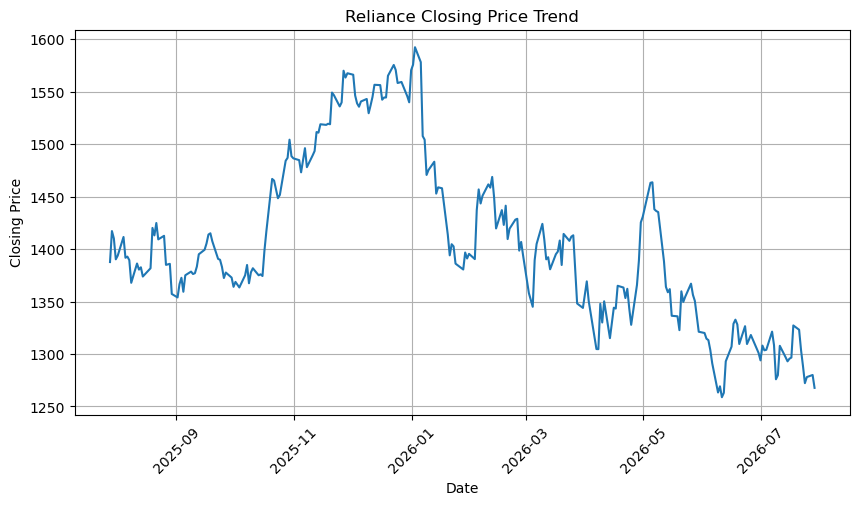

In [11]:
plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['Close'])

plt.title("Reliance Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

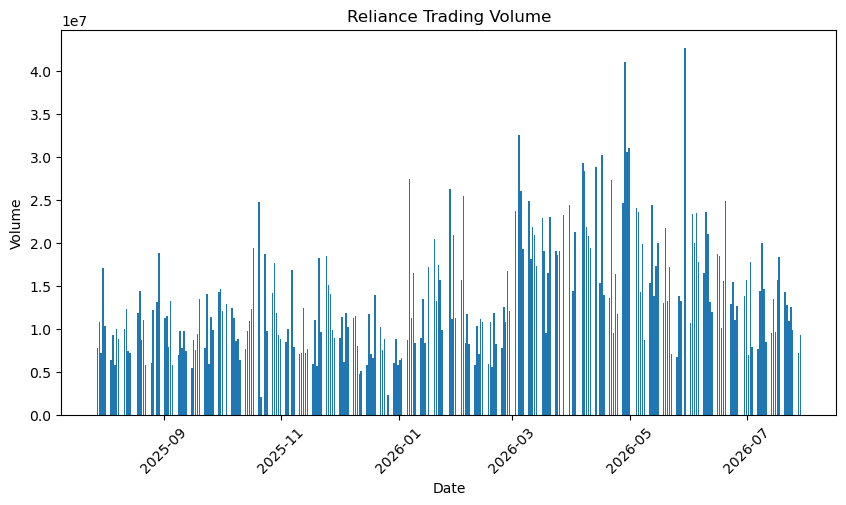

In [12]:
plt.figure(figsize=(10,5))

plt.bar(df['Date'], df['Volume'])

plt.title("Reliance Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.xticks(rotation=45)
plt.show()

In [13]:
df.loc[df['Volume'].idxmax()]

Date            2026-05-29 15:30:00
Open                         1364.0
High                         1369.0
Low                          1317.0
Close                        1321.2
Volume                     42634247
MA_7                    1351.257143
MA_30                       1374.39
Year                           2026
Month                           May
Daily Return              -0.021696
Name: 204, dtype: object

In [14]:
print("Highest Closing Price:", df['Close'].max())
print("Lowest Closing Price:", df['Close'].min())
print("Average Closing Price:", df['Close'].mean())

Highest Closing Price: 1592.3
Lowest Closing Price: 1258.8
Average Closing Price: 1406.6121951219511


In [15]:
print("Last Closing Price:", df['Close'].iloc[-1])

Last Closing Price: 1267.7


### Moving Average Analysis

In [16]:
df['MA_7'] = df['Close'].rolling(window=7).mean()

In [17]:
df['MA_30'] = df['Close'].rolling(window=30).mean()

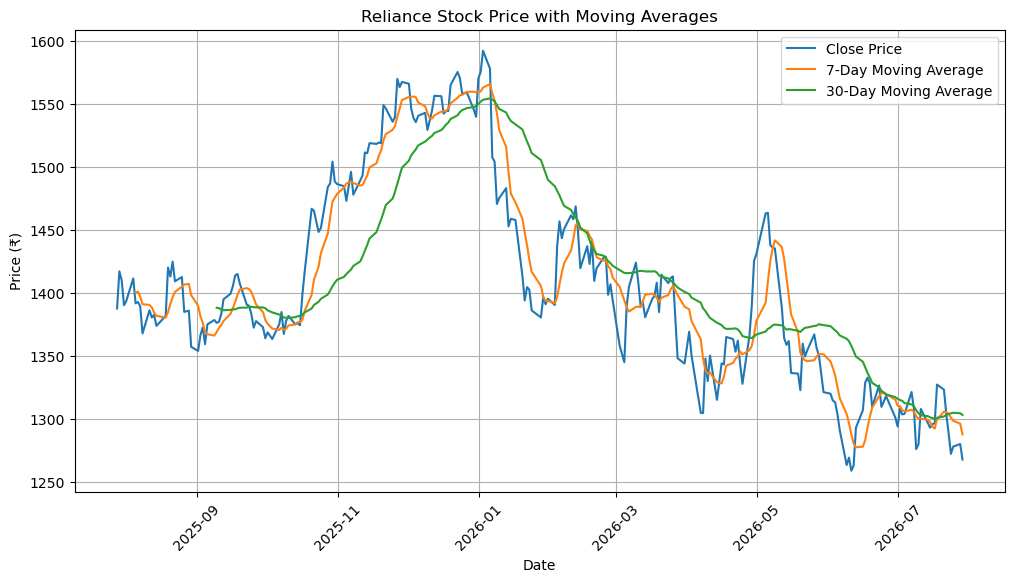

In [18]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA_7'], label='7-Day Moving Average')
plt.plot(df['Date'], df['MA_30'], label='30-Day Moving Average')

plt.title("Reliance Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.show()

In [19]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

In [20]:
monthly_avg = df.groupby(['Year', 'Month'])['Close'].mean().reset_index()

monthly_avg

,Year,Month,Close
0,2025,August,1392.594737
1,2025,December,1550.450000
2,2025,July,1401.250000
3,2025,November,1520.242105
4,2025,October,1421.009524
5,2025,September,1383.104545
6,2026,April,1354.265000
7,2026,February,1431.105000
8,2026,January,1456.040000
9,2026,July,1296.560000


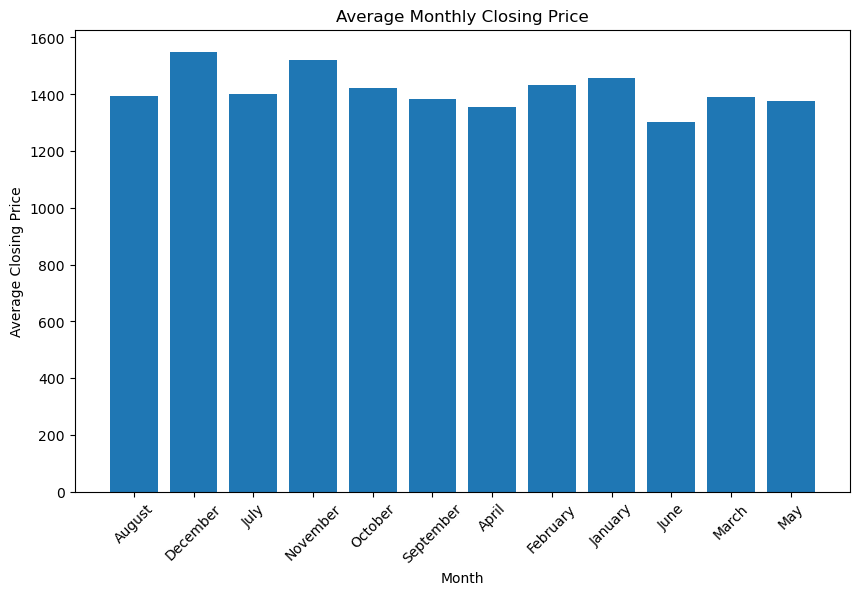

In [21]:
plt.figure(figsize=(10,6))

plt.bar(monthly_avg['Month'], monthly_avg['Close'])

plt.title("Average Monthly Closing Price")
plt.xlabel("Month")
plt.ylabel("Average Closing Price")

plt.xticks(rotation=45)
plt.show()

In [22]:
monthly_avg.sort_values(by='Close', ascending=False)

,Year,Month,Close
1,2025,December,1550.450000
3,2025,November,1520.242105
8,2026,January,1456.040000
7,2026,February,1431.105000
4,2025,October,1421.009524
2,2025,July,1401.250000
0,2025,August,1392.594737
11,2026,March,1390.410526
5,2025,September,1383.104545
12,2026,May,1376.978947


In [23]:
correlation = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

correlation

,Open,High,Low,Close,Volume
Open,1.000000,0.991521,0.990090,0.979334,-0.308758
High,0.991521,1.000000,0.989859,0.990995,-0.279876
Low,0.990090,0.989859,1.000000,0.992497,-0.356549
Close,0.979334,0.990995,0.992497,1.000000,-0.324241
Volume,-0.308758,-0.279876,-0.356549,-0.324241,1.000000


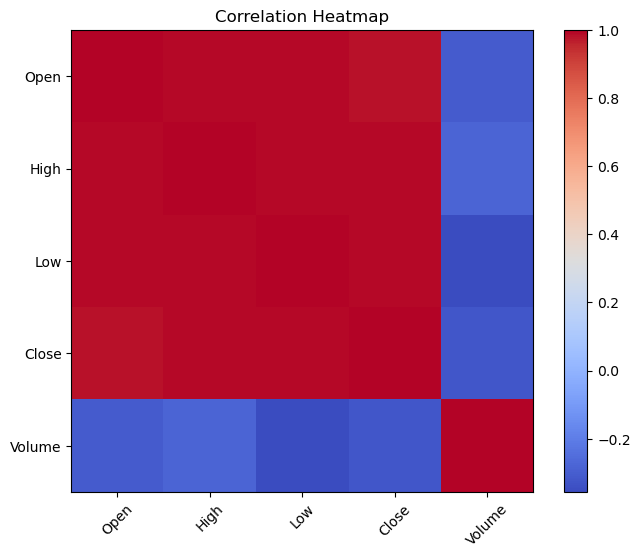

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(correlation, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [25]:
df['Daily Return'] = df['Close'].pct_change()

In [26]:
df[['Date','Close','Daily Return']].head(10)

,Date,Close,Daily Return
0,2025-07-28 15:30:00,1387.6,NaN
1,2025-07-29 15:30:00,1417.1,0.021260
2,2025-07-30 15:30:00,1410.1,-0.004940
3,2025-07-31 15:30:00,1390.2,-0.014112
4,2025-08-01 15:30:00,1393.7,0.002518
5,2025-08-04 15:30:00,1411.5,0.012772
6,2025-08-05 15:30:00,1391.7,-0.014028
7,2025-08-06 15:30:00,1392.8,0.000790
8,2025-08-07 15:30:00,1389.4,-0.002441
9,2025-08-08 15:30:00,1367.8,-0.015546


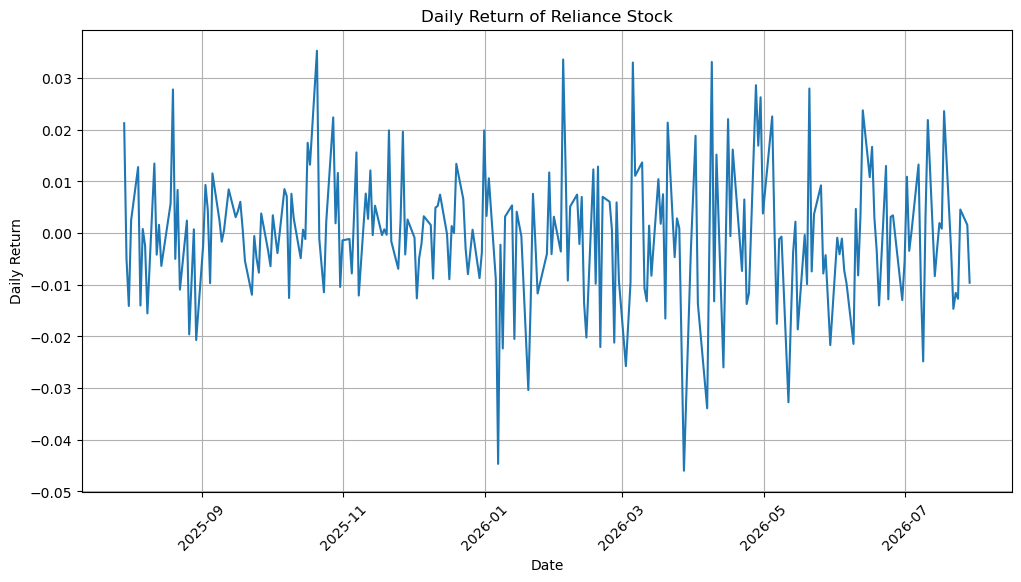

In [27]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Daily Return'])

plt.title("Daily Return of Reliance Stock")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.grid(True)

plt.xticks(rotation=45)

plt.show()

In [28]:
print("Maximum Daily Return :", df['Daily Return'].max())

print("Minimum Daily Return :", df['Daily Return'].min())

print("Average Daily Return :", df['Daily Return'].mean())

print("Daily Return Standard Deviation :", df['Daily Return'].std())

Maximum Daily Return : 0.03529079616036146
Minimum Daily Return : -0.04599816007359703
Average Daily Return : -0.0002867057099350235
Daily Return Standard Deviation : 0.012830180889072978


In [29]:
df.to_csv("row_data.csv", index=False)

In [30]:
df.to_csv("row_data.csv", index=False)

In [31]:
df.to_csv("row_data.csv", index=False)

In [32]:
import os
print(os.getcwd())

C:\Users\admin\Market Any
